# Seasonal Analysis from PostgreSQL

This notebook connects to the live `zava` database, reads the retail sales data, and shows the seasonal pattern as both a table and a bar chart.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from psycopg2.extras import RealDictCursor

DB_CONFIG = {
    'host': 'db',
    'port': 5432,
    'dbname': 'zava',
    'user': 'postgres',
    'password': 'P@ssw0rd!',
}

def fetch_query(query):
    conn = psycopg2.connect(**DB_CONFIG)
    try:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            cur.execute(query)
            rows = cur.fetchall()
    finally:
        conn.close()
    return pd.DataFrame(rows)

print('Connected to the database session successfully.')

Connected to the database session successfully.


In [2]:
query = """
WITH monthly_category_sales AS (
    SELECT
        c.category_name,
        EXTRACT(MONTH FROM o.order_date)::int AS month_num,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.total_amount) AS revenue
    FROM retail.orders o
    JOIN retail.order_items oi
      ON oi.order_id = o.order_id
    JOIN retail.products p
      ON p.product_id = oi.product_id
    JOIN retail.categories c
      ON c.category_id = p.category_id
    GROUP BY c.category_name, EXTRACT(MONTH FROM o.order_date)::int
),
month_names AS (
    SELECT 1 AS month_num, 'Jan' AS month_name
    UNION ALL SELECT 2, 'Feb'
    UNION ALL SELECT 3, 'Mar'
    UNION ALL SELECT 4, 'Apr'
    UNION ALL SELECT 5, 'May'
    UNION ALL SELECT 6, 'Jun'
    UNION ALL SELECT 7, 'Jul'
    UNION ALL SELECT 8, 'Aug'
    UNION ALL SELECT 9, 'Sep'
    UNION ALL SELECT 10, 'Oct'
    UNION ALL SELECT 11, 'Nov'
    UNION ALL SELECT 12, 'Dec'
),
category_months AS (
    SELECT
        s.category_name,
        m.month_num,
        m.month_name,
        COALESCE(s.units_sold, 0) AS units_sold,
        COALESCE(s.revenue, 0) AS revenue
    FROM (
        SELECT DISTINCT category_name FROM retail.categories
    ) cat
    CROSS JOIN month_names m
    LEFT JOIN monthly_category_sales s
      ON s.category_name = cat.category_name
     AND s.month_num = m.month_num
),
normalized AS (
    SELECT
        category_name,
        month_num,
        month_name,
        units_sold,
        AVG(units_sold) OVER (PARTITION BY category_name) AS avg_units,
        units_sold / NULLIF(AVG(units_sold) OVER (PARTITION BY category_name), 0) AS seasonal_index
    FROM category_months
),
ranked AS (
    SELECT
        *,
        MAX(seasonal_index) OVER (PARTITION BY category_name) AS peak_index,
        MIN(seasonal_index) OVER (PARTITION BY category_name) AS low_index,
        ROW_NUMBER() OVER (PARTITION BY category_name ORDER BY seasonal_index DESC) AS peak_rank,
        ROW_NUMBER() OVER (PARTITION BY category_name ORDER BY seasonal_index ASC) AS low_rank
    FROM normalized
),
summary AS (
    SELECT DISTINCT
        category_name,
        peak_index - low_index AS seasonal_swing,
        peak_index,
        low_index
    FROM ranked
)
SELECT
    category_name,
    seasonal_swing,
    (SELECT month_name FROM ranked r WHERE r.category_name = s.category_name AND r.peak_rank = 1) AS peak_month,
    (SELECT month_name FROM ranked r WHERE r.category_name = s.category_name AND r.low_rank = 1) AS low_month
FROM summary s
ORDER BY seasonal_swing DESC;
"""
seasonal_df = fetch_query(query)
seasonal_df

,category_name,seasonal_swing,peak_month,low_month
0,GARDEN & OUTDOOR,0.93496373056994814093,Apr,Dec
1,STORAGE & ORGANIZATION,0.88575149064491805881,Feb,Jul
2,HARDWARE,0.60889256512129302777,Oct,Jun
3,LUMBER & BUILDING MATERIALS,0.56945045434876680732,Jul,Dec
4,ELECTRICAL,0.56540984480827690266,Dec,Apr
5,PAINT & FINISHES,0.48135274776890556839,Mar,Nov
6,POWER TOOLS,0.47718865598027131134,Aug,Dec
7,PLUMBING,0.42590246138085354863,Oct,Aug
8,HAND TOOLS,0.19739382929724934128,Aug,Dec


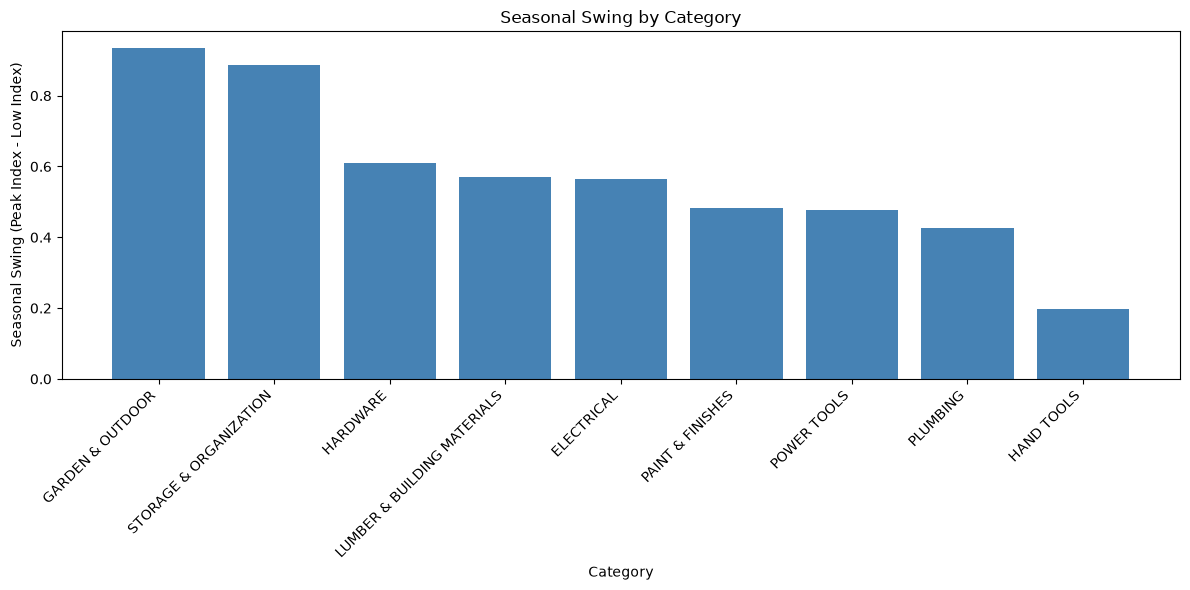

In [3]:
%matplotlib inline
plt.figure(figsize=(12, 6))
plt.bar(seasonal_df['category_name'], seasonal_df['seasonal_swing'], color='steelblue')
plt.title('Seasonal Swing by Category')
plt.xlabel('Category')
plt.ylabel('Seasonal Swing (Peak Index - Low Index)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()